# Ensembl VEP Annotations









In [7]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### SpliceAI

In [196]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path)

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_SpliceVarDB_splicing.csv.gz")

In [197]:
vep_df["Location"] = (
    vep_df["chromosome"].str.removeprefix("chr").astype(str)
    + ":"
    + vep_df["position"].astype(str)
    + "-"
    + vep_df["position"].astype(str)
) 

### All others (Flashzoi)

In [ ]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.csv.gz")

In [153]:
vep_df["Location"] = vep_df["chrom"].astype(str) + ":" + vep_df["chromStart"].astype(str) + "-" + vep_df["chromStart"].astype(str)

## Filter and merge annotation files

In [198]:
cv_annot = ev.filter_annotations(
    df= vep_df,
    df_filters = {"Location": "Location"}, 
    cache_search = os.path.join(os.path.expanduser("~/projects/data/ensemblVEP"), "clinvarVEP*"),
    cached_file = cached_file,
    # force = True
)  
cv_annot.head()

(27841, 490)


,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,MutationTaster_score,MutationTaster_trees_beni

In [199]:
# Aggregate VEP scores
vep_df["is_ref"] = vep_df["sample"] == "REF"
agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified"] if x in vep_df.columns]
vep_agg = vep_df.groupby(agg_cols, observed=True).agg({"VEP": "mean"}).reset_index()
print("vep_agg.shape:",vep_agg.shape)

# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_agg.columns]
vep_annot = vep_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_annot.shape:",vep_annot.shape)
vep_annot.head() 

vep_agg.shape: (16469, 5)
vep_annot.shape: (6038, 494)


,is_ref,site,spliceogenicity,CLNSIG_simplified,VEP,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_p

Compute correlations between VEP scores and EnsemblVEP annotations. 

Then compare the difference in VEP scores between reference-derived VEPs and averaged non-reference-derived (personalized) VEPs.

In [200]:
r2_df = ev.run_correlation_analysis(vep_annot, 
                                    ANNOT_COLS=ev.ANNOT_COLS, 
                                    # transform="exp2", 
                                    # method="pearson"
                                    )

Calculating Spearman r:  69%|██████▉   | 91/132 [00:01<00:00, 52.77it/s]<string>:60: UserWarning: Error converting VEP and DEOGEN2_score to float
<string>:60: UserWarning: Error converting VEP and ESM1b_score to float
Calculating Spearman r:  78%|███████▊  | 103/132 [00:02<00:00, 50.87it/s]<string>:60: UserWarning: Error converting VEP and MPC_score to float
<string>:60: UserWarning: Error converting VEP and MVP_score to float
<string>:60: UserWarning: Error converting VEP and MetaRNN_score to float
<string>:60: UserWarning: Error converting VEP and MutationAssessor_score to float
Calculating Spearman r:  83%|████████▎ | 110/132 [00:02<00:00, 55.63it/s]<string>:60: UserWarning: Error converting VEP and PROVEAN_pred to float
<string>:60: UserWarning: Error converting VEP and PROVEAN_score to float
<string>:60: UserWarning: Error converting VEP and PrimateAI_pred to float
Calculating Spearman r:  89%|████████▊ | 117/132 [00:02<00:00, 56.99it/s]<string>:60: UserWarning: Error converting V


R2 Results Summary:
               annotation     ref_r  nonref_r    r_diff  rabs_diff   r2_diff  \
65           Enformer_SAR -0.103445 -0.093806  0.009639  -0.009639 -0.001901   
64           Enformer_SAD -0.098607 -0.089226  0.009382  -0.009382 -0.001762   
68            mutfunc_mod  0.041692  0.049494  0.007802   0.007802  0.000711   
4   MaveDB_score_abs_mean  0.123026  0.129714  0.006689   0.006689  0.001690   
67            mutfunc_int  0.000478  0.006546  0.006068   0.006068  0.000043   
..                    ...       ...       ...       ...        ...       ...   
72         1000Gp3_EUR_AF -0.014998 -0.047208 -0.032210   0.032210  0.002004   
24                 AMR_AF -0.016920 -0.049800 -0.032880   0.032880  0.002194   
25                 EAS_AF  0.006749 -0.026648 -0.033397   0.019898  0.000665   
71         1000Gp3_EAS_AF  0.009804 -0.029085 -0.038889   0.019280  0.000750   
70         1000Gp3_AMR_AF -0.006563 -0.045531 -0.038968   0.038968  0.002030   

    ref_n  nonref_

Partial explanation of EnsemblVEP columns:
- https://useast.ensembl.org/info/docs/tools/vep/vep_formats.html#tab

In [201]:
# r2_df.loc[r2_df["ref_p"]<0.05, "ref_r"] = 0
# r2_df.loc[r2_df["nonref_p"]<0.05, "nonref_r"] = 0
# r2_df["r_diff"] = r2_df["nonref_r"] - r2_df["ref_r"]

# r2_df["combined_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])) - (r2_df["ref_r"] *(1-r2_df["ref_p"]))
# r2_df["combined_abs_diff"] = (r2_df["nonref_r"].abs() *(1-r2_df["nonref_p"])) - (r2_df["ref_r"].abs() *(1-r2_df["ref_p"]))
# r2_df["combined2_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])).pow(2) - (r2_df["ref_r"] *(1-r2_df["ref_p"])).pow(2)


<string>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


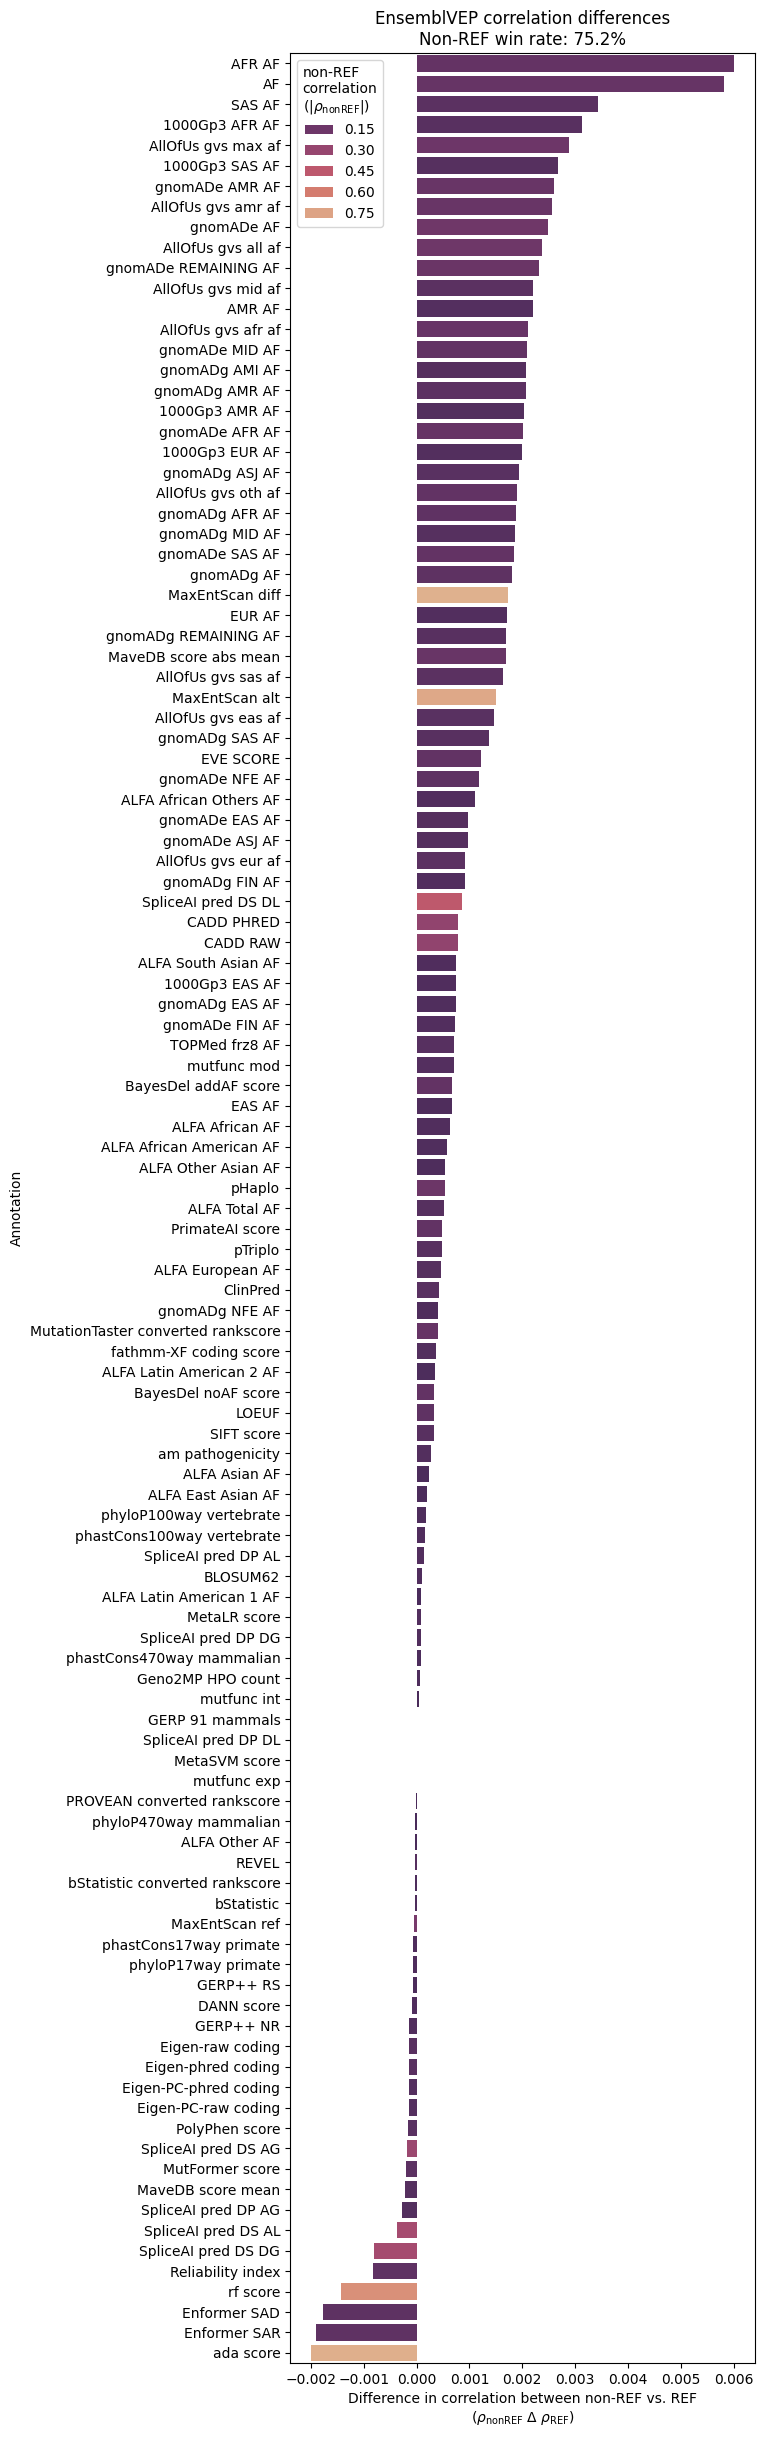

In [206]:
r2_filt = ev.plot_correlation_analysis(r2_df, 
                                       x_var="r2_diff",
                                        # min_n=20,
                                        # max_p=0.05,
                                        # min_diff=1e-10,
                                        title="EnsemblVEP correlation differences",
                                        # annotations=[x for x in ev.ANNOT_COLS if not x.lower().endswith("af") and "SpliceAI" not in x],
                                        figsize=(6, 30))